# Emotion classification from text (RoBERTa-base)



## 1. Setup

In [ ]:
pip install torchinfo

In [ ]:
# Import libraries
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

from datasets import load_dataset
import nltk
from nltk.corpus import wordnet

from transformers import (
    AutoTokenizer,                       # BPE tokenizer for RoBERTa
    AutoModelForSequenceClassification,  # RoBERTa encoder + classification head
    get_linear_schedule_with_warmup,     # LR scheduler standard for BERT fine-tuning
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
# Load dataset
raw = load_dataset("mteb/emotion")

## 2. EDA


In [ ]:
train_df = raw["train"].to_pandas()
val_df   = raw["validation"].to_pandas()
test_df  = raw["test"].to_pandas()

print("Columns:", train_df.columns.tolist())
print(f"\nRows — train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}")
print("\nFirst rows (train):")
display(train_df.head(3))

Columns: ['text', 'label', 'label_text']

Rows — train: 15956 | val: 1988 | test: 1986

First rows (train):


,text,label,label_text
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger


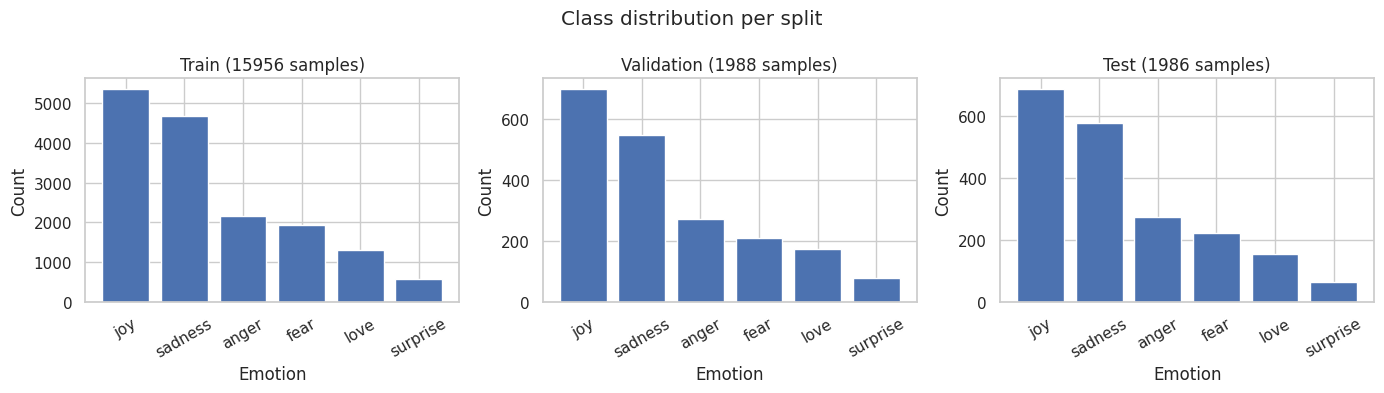


Word count stats (train):
count    15956.0
mean        19.2
std         11.0
min          3.0
25%         11.0
50%         17.0
75%         25.0
max         66.0
Name: word_count, dtype: float64


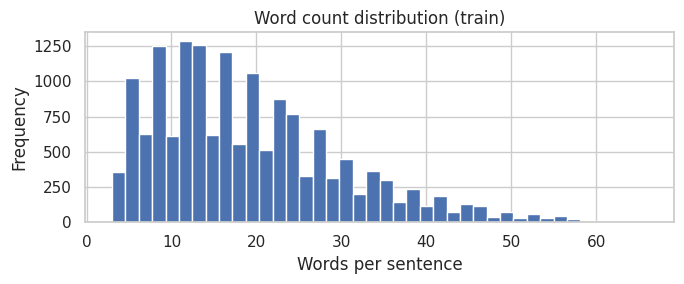

In [ ]:
# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (df, title) in zip(
    axes,
    [(train_df, "Train"), (val_df, "Validation"), (test_df, "Test")],
):
    counts = df["label_text"].value_counts()
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{title} ({len(df)} samples)")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Class distribution per split")
plt.tight_layout()
plt.show()

# Text length distribution
train_df["word_count"] = train_df["text"].map(lambda s: len(s.split()))
print("\nWord count stats (train):")
print(train_df["word_count"].describe().round(1))

plt.figure(figsize=(7, 3))
plt.hist(train_df["word_count"], bins=40, edgecolor="white")
plt.title("Word count distribution (train)")
plt.xlabel("Words per sentence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 3. Tokenizer

In [ ]:
# Model identifier on the HuggingFace Hub
MODEL_NAME = "roberta-base"

# max_length: cap sequences at 128 BPE tokens.
MAX_LEN = 128

# Load the pre-trained BPE tokenizer for RoBERTa-base
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer class :", type(tokenizer).__name__)
print("Vocab size       :", tokenizer.vocab_size)
print("Max model length :", tokenizer.model_max_length)

Tokenizer class : RobertaTokenizer
Vocab size       : 50265
Max model length : 512


In [ ]:
# Preview tokenisation on a sample sentence to understand the output format.
sample_text = train_df["text"].iloc[69]

encoding = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

print("Original text  :", sample_text)
print()
print("BPE tokens     :", tokenizer.convert_ids_to_tokens(encoding["input_ids"][0]))
print()
print("input_ids      :", encoding["input_ids"][0].tolist())
print()
print("attention_mask :", encoding["attention_mask"][0].tolist())
print()

print("token_type_ids : not used by RoBERTa (NSP objective removed)")
print()
print("Sequence length after padding/truncation:", encoding["input_ids"].shape[1])

Original text  : i was feeling brave when i bought it and clearly when i was doing my makeup

BPE tokens     : ['<s>', 'i', 'Ġwas', 'Ġfeeling', 'Ġbrave', 'Ġwhen', 'Ġi', 'Ġbought', 'Ġit', 'Ġand', 'Ġclearly', 'Ġwhen', 'Ġi', 'Ġwas', 'Ġdoing', 'Ġmy', 'Ġmakeup', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad

## 4. Label preparation

In [ ]:
labels_sorted = sorted(train_df["label"].unique())
assert labels_sorted == list(range(len(labels_sorted))), "Labels should be 0..K-1"
num_classes = len(labels_sorted)
id2label = train_df.drop_duplicates("label").set_index("label")["label_text"].to_dict()
label2id = {v: k for k, v in id2label.items()}
print("num_classes:", num_classes)
print("id2label   :", id2label)

num_classes: 6
id2label   : {0: 'sadness', 3: 'anger', 2: 'love', 5: 'surprise', 4: 'fear', 1: 'joy'}


## 5. Split dataset


In [ ]:
# RoBERTa's tokenizer handles all normalisation internally
train_texts = train_df["text"].tolist()
val_texts   = val_df["text"].tolist()
test_texts  = test_df["text"].tolist()

y_train = train_df["label"].to_numpy()
y_val   = val_df["label"].to_numpy()
y_test  = test_df["label"].to_numpy()

print("Split sizes:", len(train_texts), len(val_texts), len(test_texts))

Split sizes: 15956 1988 1986


## 6. Data Augmentation

In [ ]:
# Download required NLTK resources
nltk.download('wordnet',                        quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4',                        quiet=True)


def _wn_pos(tag):
    # Map Penn Treebank POS tag to a WordNet POS constant.
    return {'J': wordnet.ADJ, 'V': wordnet.VERB,
            'N': wordnet.NOUN, 'R': wordnet.ADV}.get(tag[0])


def synonym_substitution(text, p_swap=0.30, rng=None):
    # Replace the content words with a random WordNet synonym.
    # Returns the augmented string, or the original if no substitution is possible.

    if rng is None:
        rng = np.random.default_rng()
    words     = text.split()
    pos_tags  = nltk.pos_tag(words)
    new_words = words.copy()
    for i, (word, tag) in enumerate(pos_tags):
        if rng.random() > p_swap:
            continue
        wn_pos   = _wn_pos(tag)
        if wn_pos is None:
            continue
        synonyms = [
            lemma.name().replace('_', ' ')
            for syn in wordnet.synsets(word, pos=wn_pos)
            for lemma in syn.lemmas()
            if lemma.name().lower() != word.lower()
        ]
        if synonyms:
            new_words[i] = rng.choice(synonyms)
    return ' '.join(new_words)


# Augmentation schedule
AUG_SCHEDULE = {
    label2id['surprise']: [0.20, 0.30, 0.40],    # ×3
    label2id['love']:     [0.20, 0.35],          # ×2
    label2id['fear']:     [0.25],                # ×1
}

rng_aug   = np.random.default_rng(SEED)
aug_texts, aug_labels = [], []

for text, label in zip(train_texts, y_train):
    for p in AUG_SCHEDULE.get(label, []):
        aug_texts.append(synonym_substitution(text, p_swap=p, rng=rng_aug))
        aug_labels.append(label)

# Append and shuffle
train_texts = train_texts + aug_texts
y_train     = np.concatenate([y_train, np.array(aug_labels, dtype=y_train.dtype)])
perm        = rng_aug.permutation(len(train_texts))
train_texts = [train_texts[i] for i in perm]
y_train     = y_train[perm]

# Report new class distribution
orig_counts  = np.bincount(y_train, minlength=num_classes)
print(f'Training set after augmentation: {len(train_texts)} samples (+{len(aug_texts)} synthetic)')
print('\nClass counts after augmentation:')
for lbl, cnt in enumerate(orig_counts):
    copies = len(AUG_SCHEDULE.get(lbl, []))
    tag    = f' (×{copies+1} total)' if copies else ''
    print(f'  {id2label[lbl]:10s}  {cnt:5d}{tag}')


Training set after augmentation: 22185 samples (+6229 synthetic)

Class counts after augmentation:
  sadness      4663
  joy          5345
  love         3891 (×3 total)
  anger        2152
  fear         3862 (×2 total)
  surprise     2272 (×4 total)


## 7. Tokenisation & encoding

In [ ]:
def batch_encode(texts, tokenizer, max_len):

    # Tokenise a list of texts and return padded / truncated encodings.
    enc = tokenizer(
        texts,
        max_length=max_len,
        padding="max_length",        # pad all sequences to exactly max_len
        truncation=True,             # truncate sequences longer than max_len
        return_tensors="pt",         # return PyTorch tensors directly
        return_token_type_ids=False, # not needed for RoBERTa
    )
    return {
        "input_ids":      enc["input_ids"],       # (N, max_len)
        "attention_mask": enc["attention_mask"],   # (N, max_len)
    }


print("Encoding train split...")
enc_train = batch_encode(train_texts, tokenizer, MAX_LEN)

print("Encoding validation split...")
enc_val = batch_encode(val_texts, tokenizer, MAX_LEN)

print("Encoding test split...")
enc_test = batch_encode(test_texts, tokenizer, MAX_LEN)

print()
print("Shapes:")
print("  input_ids  train:", enc_train["input_ids"].shape)
print("  input_ids  val  :", enc_val["input_ids"].shape)
print("  input_ids  test :", enc_test["input_ids"].shape)

Encoding train split...
Encoding validation split...
Encoding test split...

Shapes:
  input_ids  train: torch.Size([22185, 128])
  input_ids  val  : torch.Size([1988, 128])
  input_ids  test : torch.Size([1986, 128])


## 8. PyTorch Dataset / DataLoader

In [ ]:
class EmotionDataset(Dataset):

    # Wraps pre-computed tokeniser encodings and integer labels into a PyTorch Dataset.
    def __init__(self, encodings, labels):
        # encodings: dict with 'input_ids' and 'attention_mask' tensors
        self.input_ids      = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return (
            self.input_ids[i],       # (max_len,)
            self.attention_mask[i],  # (max_len,)
            self.labels[i],          # scalar
        )


def make_loader(encodings, labels, batch_size, shuffle):
    ds = EmotionDataset(encodings, labels)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 32

train_loader = make_loader(enc_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(enc_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(enc_test,  y_test,  BATCH_SIZE, shuffle=False)

In [ ]:
def count_params(m):
    # Count number of parameters
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


# AutoModelForSequenceClassification automatically attaches a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels = num_classes,
    id2label   = id2label,
    label2id   = label2id,
).to(device)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
summary(model, input_size=[(BATCH_SIZE, MAX_LEN), (BATCH_SIZE, MAX_LEN)], dtypes=[torch.long, torch.long])

Layer (type:depth-idx)                                       Output Shape              Param #
RobertaForSequenceClassification                             [32, 6]                   --
├─RobertaModel: 1-1                                          [32, 128, 768]            --
│    └─RobertaEmbeddings: 2-1                                [32, 128, 768]            --
│    │    └─Embedding: 3-1                                   [32, 128, 768]            38,603,520
│    │    └─Embedding: 3-2                                   [32, 128, 768]            768
│    │    └─Embedding: 3-3                                   [32, 128, 768]            394,752
│    │    └─LayerNorm: 3-4                                   [32, 128, 768]            1,536
│    │    └─Dropout: 3-5                                     [32, 128, 768]            --
│    └─RobertaEncoder: 2-2                                   [32, 128, 768]            --
│    │    └─ModuleList: 3-6                                  --               

In [ ]:
# Quick sanity check: one forward pass to verify output shapes
input_ids_demo, mask_demo, _ = next(iter(train_loader))
with torch.no_grad():
    out = model(
        input_ids      = input_ids_demo.to(device),
        attention_mask = mask_demo.to(device),
    )

# AutoModelForSequenceClassification returns a SequenceClassifierOutput dataclass.
print('Output type  :', type(out).__name__)
print('Logits shape :', out.logits.shape)  # expected: (BATCH_SIZE, num_classes)


Output type  : SequenceClassifierOutput
Logits shape : torch.Size([32, 6])


## 9. Training Setup

In [ ]:
# Train the model for one epoch
def train_one_epoch(model, loader, optimizer, scheduler, criterion):

    # Set model to training mode
    model.train()
    total_loss = 0.0

    # Loop through batches from DataLoader
    for input_ids, attention_mask, labels in loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels         = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        # Forward pass: model returns a SequenceClassifierOutput dataclass
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = output.logits  # (B, num_classes)

        # Compute loss between predicted logits and true labels
        loss = criterion(logits, labels)

        # Backpropagation: compute gradients
        loss.backward()

        # Gradient clipping helps stabilise transformer fine-tuning
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update model parameters
        optimizer.step()

        # Step the LR scheduler once per batch (transformer convention)
        scheduler.step()

        # Accumulate total loss weighted by batch size
        total_loss += loss.item() * input_ids.size(0)

    # Return average loss over the whole training set
    return total_loss / len(loader.dataset)


# Evaluate model on validation or test set
@torch.no_grad()
def evaluate(model, loader, criterion=None):

    # Set model to evaluation mode - disables dropout
    model.eval()
    total_loss = 0.0
    all_y, all_p = [], []

    for input_ids, attention_mask, labels in loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels         = labels.to(device)

        # Forward pass
        output = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = output.logits  # (B, num_classes)

        # Compute loss only if criterion is provided
        if criterion is not None:
            total_loss += criterion(logits, labels).item() * input_ids.size(0)

        # Predicted class = index of highest logit
        all_p.append(logits.argmax(dim=-1).cpu().numpy())

        # Store true labels
        all_y.append(labels.cpu().numpy())

    # Merge all batches into full arrays
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)

    # Compute evaluation metrics
    metrics = {
        "acc":         accuracy_score(y_true, y_pred),
        "macro_f1":    f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    # Add average loss if criterion was used
    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, y_true, y_pred


# Training setup
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    patience=7,
    label_smoothing=0.05,
):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    no_decay  = {'bias', 'LayerNorm.weight'}
    optimizer = torch.optim.AdamW([
        {'params': [p for n, p in model.named_parameters()
                    if not any(nd in n for nd in no_decay)],
         'weight_decay': weight_decay},
        {'params': [p for n, p in model.named_parameters()
                    if any(nd in n for nd in no_decay)],
         'weight_decay': 0.0},
    ], lr=lr)

    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

    history    = {'train_loss': [], 'val_loss': [], 'val_macro_f1': [], 'val_acc': []}
    best_state = None
    best_f1    = -1.0
    stale      = 0

    for ep in range(1, epochs + 1):
        tl       = train_one_epoch(model, train_loader, optimizer, scheduler, criterion)
        vm, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tl)
        history['val_loss'].append(vm['loss'])
        history['val_macro_f1'].append(vm['macro_f1'])
        history['val_acc'].append(vm['acc'])

        if vm['macro_f1'] > best_f1 + 1e-5:
            best_f1    = vm['macro_f1']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale      = 0
        else:
            stale += 1

        print(f'Epoch {ep:02d} train_loss={tl:.4f} val_loss={vm["loss"]:.4f} '
              f'val_acc={vm["acc"]:.4f} val_macro_f1={vm["macro_f1"]:.4f}')

        if stale >= patience:
            print(f'Early stopping at epoch {ep} '
                  f'(no val macro-F1 improvement for {patience} epochs).')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_f1


def plot_history(history, title='Training'):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3))
    ax[0].plot(history['train_loss'], label='train')
    ax[0].plot(history['val_loss'],   label='val')
    ax[0].set_title('Loss'); ax[0].legend()
    ax[1].plot(history['val_macro_f1'], label='val macro-F1')
    ax[1].plot(history['val_acc'],      label='val acc', alpha=0.6)
    ax[1].set_title('Val metrics'); ax[1].legend()
    plt.suptitle(title); plt.tight_layout(); plt.show()


## 10. Train RoBERTa-base

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total steps: 20820 | Warmup steps: 2082
Epoch 01 train_loss=1.3052 val_loss=0.5859 val_acc=0.8521 val_macro_f1=0.8179
Epoch 02 train_loss=0.5241 val_loss=0.4308 val_acc=0.9235 val_macro_f1=0.8936
Epoch 03 train_loss=0.4174 val_loss=0.3708 val_acc=0.9361 val_macro_f1=0.9131
Epoch 04 train_loss=0.3705 val_loss=0.3550 val_acc=0.9386 val_macro_f1=0.9141
Epoch 05 train_loss=0.3331 val_loss=0.3696 val_acc=0.9416 val_macro_f1=0.9168
Epoch 06 train_loss=0.3127 val_loss=0.4202 val_acc=0.9316 val_macro_f1=0.9038
Epoch 07 train_loss=0.2919 val_loss=0.4278 val_acc=0.9411 val_macro_f1=0.9196
Epoch 08 train_loss=0.2765 val_loss=0.4401 val_acc=0.9386 val_macro_f1=0.9144
Epoch 09 train_loss=0.2700 val_loss=0.4534 val_acc=0.9401 val_macro_f1=0.9126
Epoch 10 train_loss=0.2631 val_loss=0.4532 val_acc=0.9411 val_macro_f1=0.9187
Epoch 11 train_loss=0.2555 val_loss=0.4666 val_acc=0.9422 val_macro_f1=0.9166
Epoch 12 train_loss=0.2551 val_loss=0.4631 val_acc=0.9437 val_macro_f1=0.9193
Epoch 13 train_loss=0.24

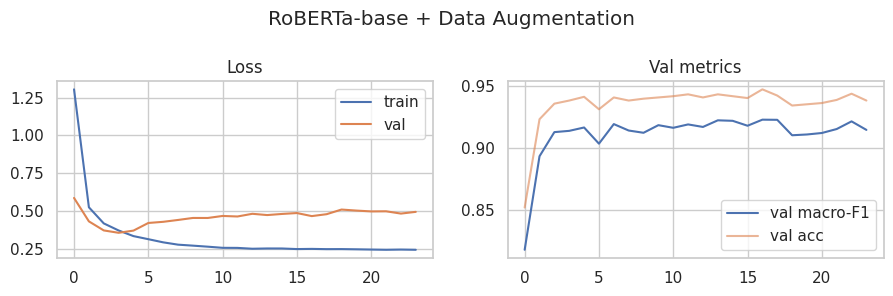

In [ ]:
# Re-initialise model to ensure clean weights before training.
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels   = num_classes,
    id2label     = id2label,
    label2id     = label2id,
).to(device)

history, best_val_f1 = train_model(
    model,
    train_loader,
    val_loader,
    epochs       = 30,
    lr           = 2e-5,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    patience     = 7,
)

print(f'\nBest val macro-F1: {best_val_f1}')
plot_history(history, title='RoBERTa-base + Data Augmentation')


## 11. Evaluation

=== Train RoBERTa-base ===
Accuracy: 0.9995943204868154

Per-class metrics:


,precision,recall,f1
sadness,0.9996,1.0000,0.9998
joy,0.9987,1.0000,0.9993
love,1.0000,0.9985,0.9992
anger,1.0000,1.0000,1.0000
fear,1.0000,0.9997,0.9999
surprise,1.0000,0.9991,0.9996



Macro    F1: 0.9996
Weighted F1: 0.9996

Full classification report:
              precision    recall  f1-score   support

     sadness       1.00      1.00      1.00      4663
         joy       1.00      1.00      1.00      5345
        love       1.00      1.00      1.00      3891
       anger       1.00      1.00      1.00      2152
        fear       1.00      1.00      1.00      3862
    surprise       1.00      1.00      1.00      2272

    accuracy                           1.00     22185
   macro avg       1.00      1.00      1.00     22185
weighted avg       1.00      1.00      1.00     22185



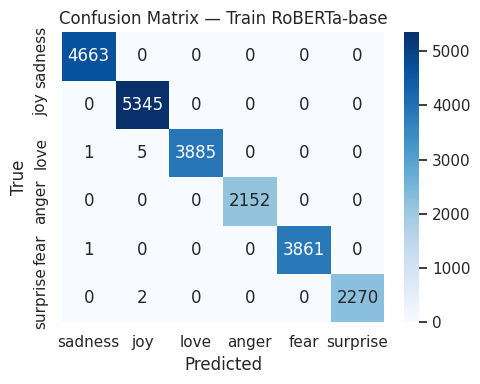

=== Validation RoBERTa-base ===
Accuracy: 0.9476861167002012

Per-class metrics:


,precision,recall,f1
sadness,0.9659,0.9782,0.9720
joy,0.9427,0.9871,0.9644
love,0.9359,0.8439,0.8875
anger,0.9444,0.9307,0.9375
fear,0.9231,0.9100,0.9165
surprise,0.9688,0.7750,0.8611



Macro    F1: 0.9232
Weighted F1: 0.9469

Full classification report:
              precision    recall  f1-score   support

     sadness       0.97      0.98      0.97       550
         joy       0.94      0.99      0.96       700
        love       0.94      0.84      0.89       173
       anger       0.94      0.93      0.94       274
        fear       0.92      0.91      0.92       211
    surprise       0.97      0.78      0.86        80

    accuracy                           0.95      1988
   macro avg       0.95      0.90      0.92      1988
weighted avg       0.95      0.95      0.95      1988



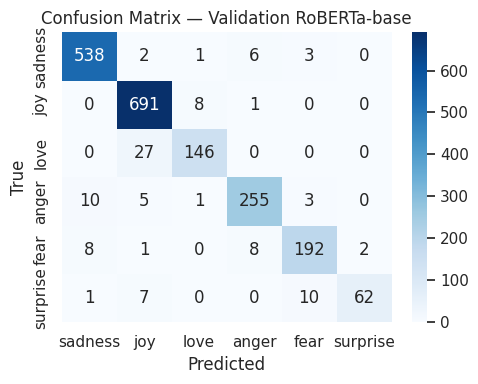

=== Test RoBERTa-base ===
Accuracy: 0.9310171198388721

Per-class metrics:


,precision,recall,f1
sadness,0.9578,0.9810,0.9693
joy,0.9208,0.9797,0.9493
love,0.9344,0.7308,0.8201
anger,0.9401,0.9161,0.9279
fear,0.8943,0.9062,0.9002
surprise,0.8667,0.6000,0.7091



Macro    F1: 0.8793
Weighted F1: 0.9286

Full classification report:
              precision    recall  f1-score   support

     sadness       0.96      0.98      0.97       579
         joy       0.92      0.98      0.95       688
        love       0.93      0.73      0.82       156
       anger       0.94      0.92      0.93       274
        fear       0.89      0.91      0.90       224
    surprise       0.87      0.60      0.71        65

    accuracy                           0.93      1986
   macro avg       0.92      0.85      0.88      1986
weighted avg       0.93      0.93      0.93      1986



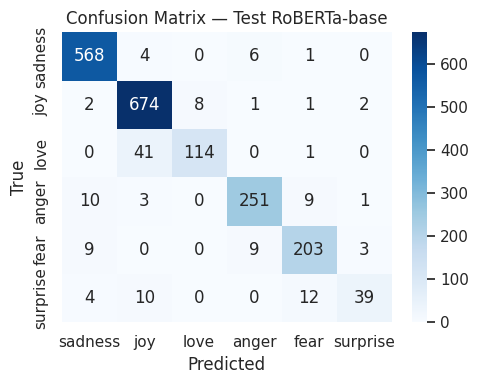


=== Summary across splits ===


,split,accuracy,macro_f1,weighted_f1
0,Train,0.9996,0.9996,0.9996
1,Validation,0.9477,0.9232,0.9469
2,Test,0.9310,0.8793,0.9286


In [ ]:
def full_report(y_true, y_pred, split_name="val"):

    # Create class names in label-id order
    names = [id2label[i] for i in sorted(id2label.keys())]

    # Print split name
    print(f"=== {split_name} ===")

    # Print overall accuracy
    print("Accuracy:", accuracy_score(y_true, y_pred))

    # Compute per-class precision, recall, and F1
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=sorted(id2label.keys()),
    )

    # Assemble per-class metrics into a DataFrame for readability
    metrics_df = pd.DataFrame(
        {"precision": p, "recall": r, "f1": f1},
        index=names,
    ).round(4)
    print("\nPer-class metrics:")
    display(metrics_df)

    # Print macro and weighted averages
    print("\nMacro    F1:", round(f1_score(y_true, y_pred, average="macro"),    4))
    print("Weighted F1:", round(f1_score(y_true, y_pred, average="weighted"), 4))

    # Full sklearn classification report
    print("\nFull classification report:")
    print(classification_report(y_true, y_pred, target_names=names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=names,
        yticklabels=names,
        cmap="Blues",
    )
    plt.title(f"Confusion Matrix — {split_name}")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return cm


# Build a shared criterion for evaluation (must match training criterion)
_eval_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Evaluate on train split
_, ytr_t, ytr_p = evaluate(model, train_loader, _eval_criterion)
full_report(ytr_t, ytr_p, "Train RoBERTa-base")

# Evaluate on validation split
_, yv_t, yv_p = evaluate(model, val_loader, _eval_criterion)
full_report(yv_t, yv_p, "Validation RoBERTa-base")

# Evaluate on test split
_, yt_t, yt_p = evaluate(model, test_loader, _eval_criterion)
full_report(yt_t, yt_p, "Test RoBERTa-base")

# Summary table — macro-F1 across all three splits
summary_df = pd.DataFrame({
    "split":      ["Train", "Validation", "Test"],
    "accuracy":   [accuracy_score(ytr_t, ytr_p),
                   accuracy_score(yv_t,  yv_p),
                   accuracy_score(yt_t,  yt_p)],
    "macro_f1":   [f1_score(ytr_t, ytr_p, average="macro"),
                   f1_score(yv_t,  yv_p,  average="macro"),
                   f1_score(yt_t,  yt_p,  average="macro")],
    "weighted_f1":[f1_score(ytr_t, ytr_p, average="weighted"),
                   f1_score(yv_t,  yv_p,  average="weighted"),
                   f1_score(yt_t,  yt_p,  average="weighted")],
}).round(4)
print("\n=== Summary across splits ===")
display(summary_df)


## 12. Error analysis


In [ ]:
# Run evaluation on the validation set
_, yv_t, yv_p = evaluate(model, val_loader, None)

# Create ordered class names from label ids
names = [id2label[i] for i in sorted(id2label.keys())]

# Build confusion matrix
cm = confusion_matrix(yv_t, yv_p, labels=sorted(id2label.keys()))

# Find the most common confusion pairs
pairs = []
n = cm.shape[0]
for i in range(n):
    for j in range(n):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], names[i], names[j]))
pairs.sort(reverse=True)

# Print the most frequent confusion types
print("Top confused (true -> pred):")
for c, a, b in pairs[:8]:
    print(f"  {c:4d}  {a} -> {b}")

# Show some actual misclassified validation examples
val_texts_arr = val_df["text"].to_numpy()
wrong_idx = np.where(yv_t != yv_p)[0]
sample = np.random.default_rng(SEED).choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
print("\nSample errors (val):")
for i in sample:
    print(f"\n true={names[yv_t[i]]} pred={names[yv_p[i]]}")
    print(" ", val_texts_arr[i][:280])

# Error analysis on TEST split
_, yt_t, yt_p = evaluate(model, test_loader, None)

cm_test = confusion_matrix(yt_t, yt_p, labels=sorted(id2label.keys()))

pairs_test = []
for i in range(n):
    for j in range(n):
        if i != j and cm_test[i, j] > 0:
            pairs_test.append((cm_test[i, j], names[i], names[j]))
pairs_test.sort(reverse=True)

print("Top confused on TEST (true -> pred):")
for c, a, b in pairs_test[:8]:
    print(f"  {c:4d}  {a} -> {b}")

test_texts_arr = test_df["text"].to_numpy()
wrong_idx_test = np.where(yt_t != yt_p)[0]
sample_test = np.random.default_rng(SEED).choice(
    wrong_idx_test, size=min(12, len(wrong_idx_test)), replace=False
)
print("\nSample errors (test):")
for i in sample_test:
    print(f"\n true={names[yt_t[i]]} pred={names[yt_p[i]]}")
    print(" ", test_texts_arr[i][:280])


Top confused (true -> pred):
    27  love -> joy
    10  surprise -> fear
    10  anger -> sadness
     8  joy -> love
     8  fear -> sadness
     8  fear -> anger
     7  surprise -> joy
     6  sadness -> anger

Sample errors (val):

 true=love pred=joy
  i feel god calling me there and if he wills it i ll be a priest for him and the rest of the faithful

 true=fear pred=sadness
  that day i was alone at home after coming home from school i did not know where everyone else had gone

 true=joy pred=love
  i it seemed like forever i want to put my phone life in knowing loving feeling seeing believing trusting and caring for her

 true=love pred=joy
  i feel like a faithful servant

 true=love pred=joy
  i feel such gratitude for the generous gifts we received on our wedding day over years ago

 true=love pred=joy
  im kind of embarrassed about feeling that way though because my moms training was such a wonderfully defining part of my own life and i loved and still love

 true=anger pr